In [1]:
%reload_ext autoreload
%autoreload 2

import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo

import signs_alignment as sa
import os

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
SCORE_THRESHOLD = 0.5
Y_THRESHOLD = 35  # for grouping signs into lines
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

In [2]:
sa.register_all_modules()
model = init_detector(CONFIG_FILE, CHECKPOINT_FILE, device='cuda:0')

Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth


In [3]:
fragments = sa.get_available_fragments()
print(f"Found {len(fragments)} fragments with both image and annotation")
sample = fragments[0]
print(f"Processing sample: {sample}")

Found 947 fragments with both image and annotation
Processing sample: NBC.4020


In [4]:
# show groud truth boxes

img = sa.load_image(sample)
gt_boxes = sa.load_ground_truth(sample)

gt_bbox_visualizer = sa.BboxVisualizer(boxes_color=(0, 255, 0)) # green for gt
gt_bbox_visualizer.draw_boxes(img.copy(), gt_boxes)
gt_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_gt.jpg"))



In [5]:
# sign text
signs_text = sa.get_signs_from_api(sample)
if signs_text is None:
    raise ValueError(f"No sign text found for sample {sample}")
print(f"  Raw API signs (first 50 chars): {signs_text[:50]}...")

text_lines = sa.parse_api_signs(signs_text)
total_text_signs = sum(len(line) for line in text_lines)
print(f"  Text lines: {len(text_lines)}, total signs: {total_text_signs}")
# print all text lines
text_visualizer = sa.TextVisualizer(text_lines = text_lines)
text_visualizer.write_text_file(filepath = os.path.join(OUTPUT_DIR, f"debug_{sample}_text.txt"), fragment_id=sample)

  Raw API signs (first 50 chars): ABZ579 ABZ70 ABZ371 ABZ586 ABZ6
ABZ461 ABZ214 ABZ3...
  Text lines: 22, total signs: 143


/home/jebediahc/anaconda3/envs/cuneiform-ocr/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


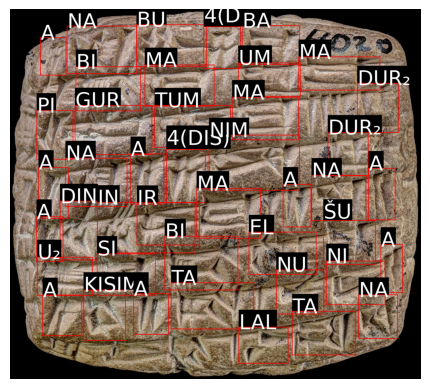

In [6]:
# detect signs
tablet_detector = sa.TabletImageDetector(model, sa.CLASSES, SCORE_THRESHOLD, keep_crops=True)
detections = tablet_detector.detect(img)

det_bbox_visualizer = sa.BboxVisualizer(boxes_color=(255, 0, 0)) # red for detections
det_bbox_visualizer.draw_boxes(img.copy(), detections)
det_bbox_visualizer.display_result(vis_opt = "save", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_det.jpg"))

cropped = tablet_detector.get_cropped_images()
exp_image = cropped[3]

det_bbox_visualizer.draw_boxes(exp_image.img.copy(), exp_image.detections)
det_bbox_visualizer.display_result(vis_opt = "draw", path = os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_image.jpg"))

In [7]:
# statistics
avg_width, avg_height = sa.compute_avg_dimensions(detections)
print(f"full image shape: {img.shape}")
print(f"Exp image shape: {exp_image.img.shape}")
print(f"Average detected sign width: {avg_width:.2f}, height: {avg_height:.2f}")

full image shape: (6451, 5078, 3)
Exp image shape: (1636, 1817, 3)
Average detected sign width: 227.35, height: 196.96


In [8]:
# Build heatmap for position probability of each class

scale_factor = 10

# Create detection heatmap using extracted function
heatmap, influence_radius, sigma = sa.create_detection_heatmap(
    exp_image.detections, 
    exp_image.img.shape, 
    sa.CLASSES, 
    scale_factor=scale_factor,
    avg_width=avg_width,
    avg_height=avg_height
)

print(f"Original image shape: {exp_image.img.shape[:2]}")
print(f"Created heatmap with shape: {heatmap.shape}")
print(f"Scale factor: 1/{scale_factor}")
print(f"Number of classes: {len(sa.CLASSES)}")
print(f"Influence radius (scaled): {influence_radius:.2f}, sigma: {sigma:.2f}")
print(f"Heatmap generated with {len(exp_image.detections)} detections")
print(f"Heatmap value range: [{heatmap.min():.3f}, {heatmap.max():.3f}]")


Original image shape: (1636, 1817)
Created heatmap with shape: (163, 181, 173)
Scale factor: 1/10
Number of classes: 173
Influence radius (scaled): 31.82, sigma: 10.61
Heatmap generated with 43 detections
Heatmap value range: [0.000, 1.000]


Class ID for sign 'A': 11
Class ID for sign 'NA': 34


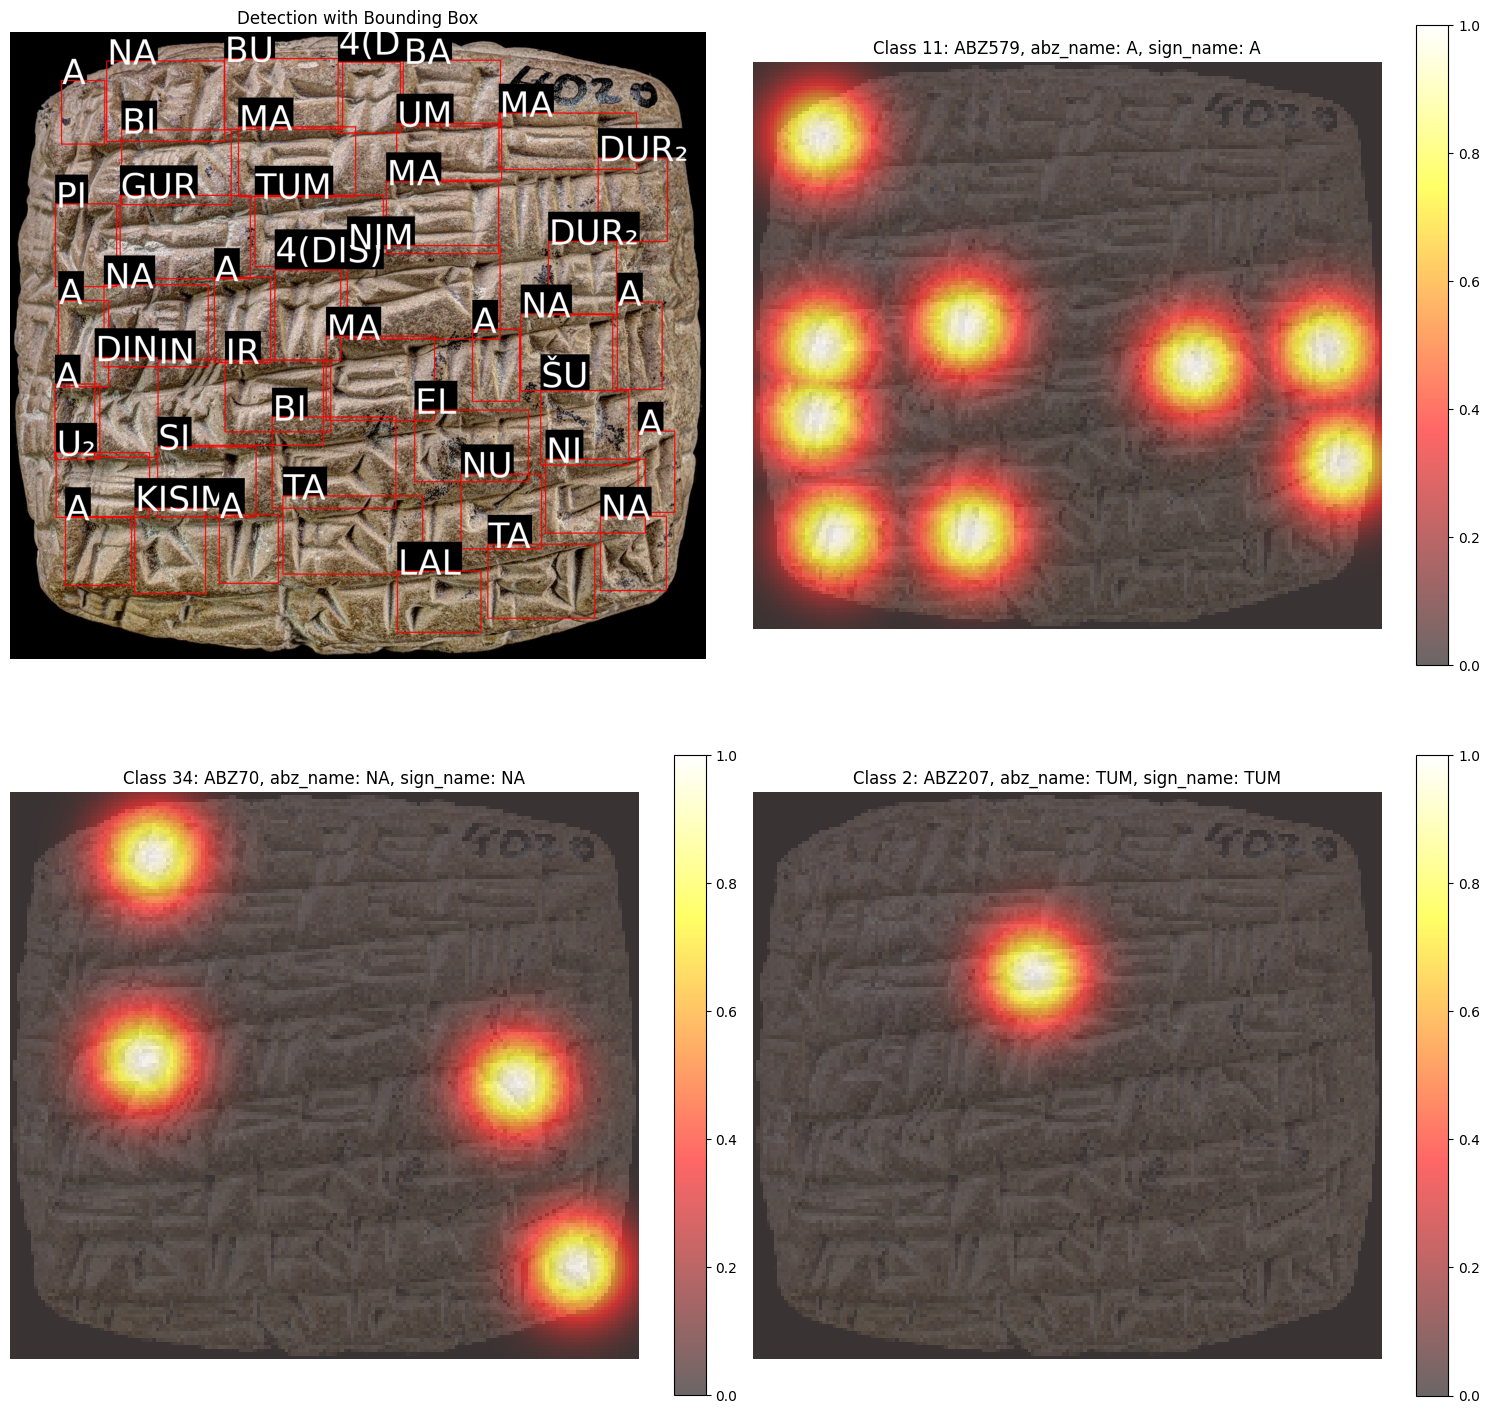

In [9]:
# Visualize exp image heatmap 

heatmap_visualizer = sa.HeatmapVisualizer()
# find class id for sign name "A"
class_id_for_A = None
class_id_for_NA = None
for i, abz_name in enumerate(sa.CLASSES):
    if sa.abz_to_sign_name(abz_name) == "A":
        class_id_for_A = i
        break
for i, abz_name in enumerate(sa.CLASSES):
    if sa.abz_to_sign_name(abz_name) == "NA":
        class_id_for_NA = i
        break
print(f"Class ID for sign 'A': {class_id_for_A}")
print(f"Class ID for sign 'NA': {class_id_for_NA}")
    
heatmap_visualizer.draw_heatmap(exp_image.img, heatmap, channels=(class_id_for_A, class_id_for_NA, 2), detection = exp_image.detections)
heatmap_visualizer.display_result(vis_opt = "draw")

In [10]:
# Create heatmap from text_lines with synthetic sign positions

# Create text heatmap using extracted function
heatmap_text, margin, influence_radius_text, sigma_text = sa.create_text_heatmap(
    text_lines, 
    sa.CLASSES, 
    avg_width, 
    avg_height, 
    scale_factor=scale_factor
)

max_row_length = max(len(line) for line in text_lines)
num_rows = len(text_lines)
total_signs_in_text = sum(len(line) for line in text_lines)

print(f"Text lines grid: {num_rows} rows, max {max_row_length} columns")
print(f"Average sign dimensions: width={avg_width:.2f}, height={avg_height:.2f}")
print(f"Text heatmap dimensions (after scaling): {heatmap_text.shape}")
print(f"Margin used: {margin:.2f}")
print(f"Gaussian parameters - influence radius: {influence_radius_text:.2f}, sigma: {sigma_text:.2f}")
print(f"Heatmap generated for {total_signs_in_text} signs from text_lines")
print(f"Heatmap value range: [{heatmap_text.min():.3f}, {heatmap_text.max():.3f}]")

Text lines grid: 22 rows, max 12 columns
Average sign dimensions: width=227.35, height=196.96
Text heatmap dimensions (after scaling): (478, 318, 173)
Margin used: 227.35
Gaussian parameters - influence radius: 31.82, sigma: 10.61
Heatmap generated for 143 signs from text_lines
Heatmap value range: [0.000, 1.000]


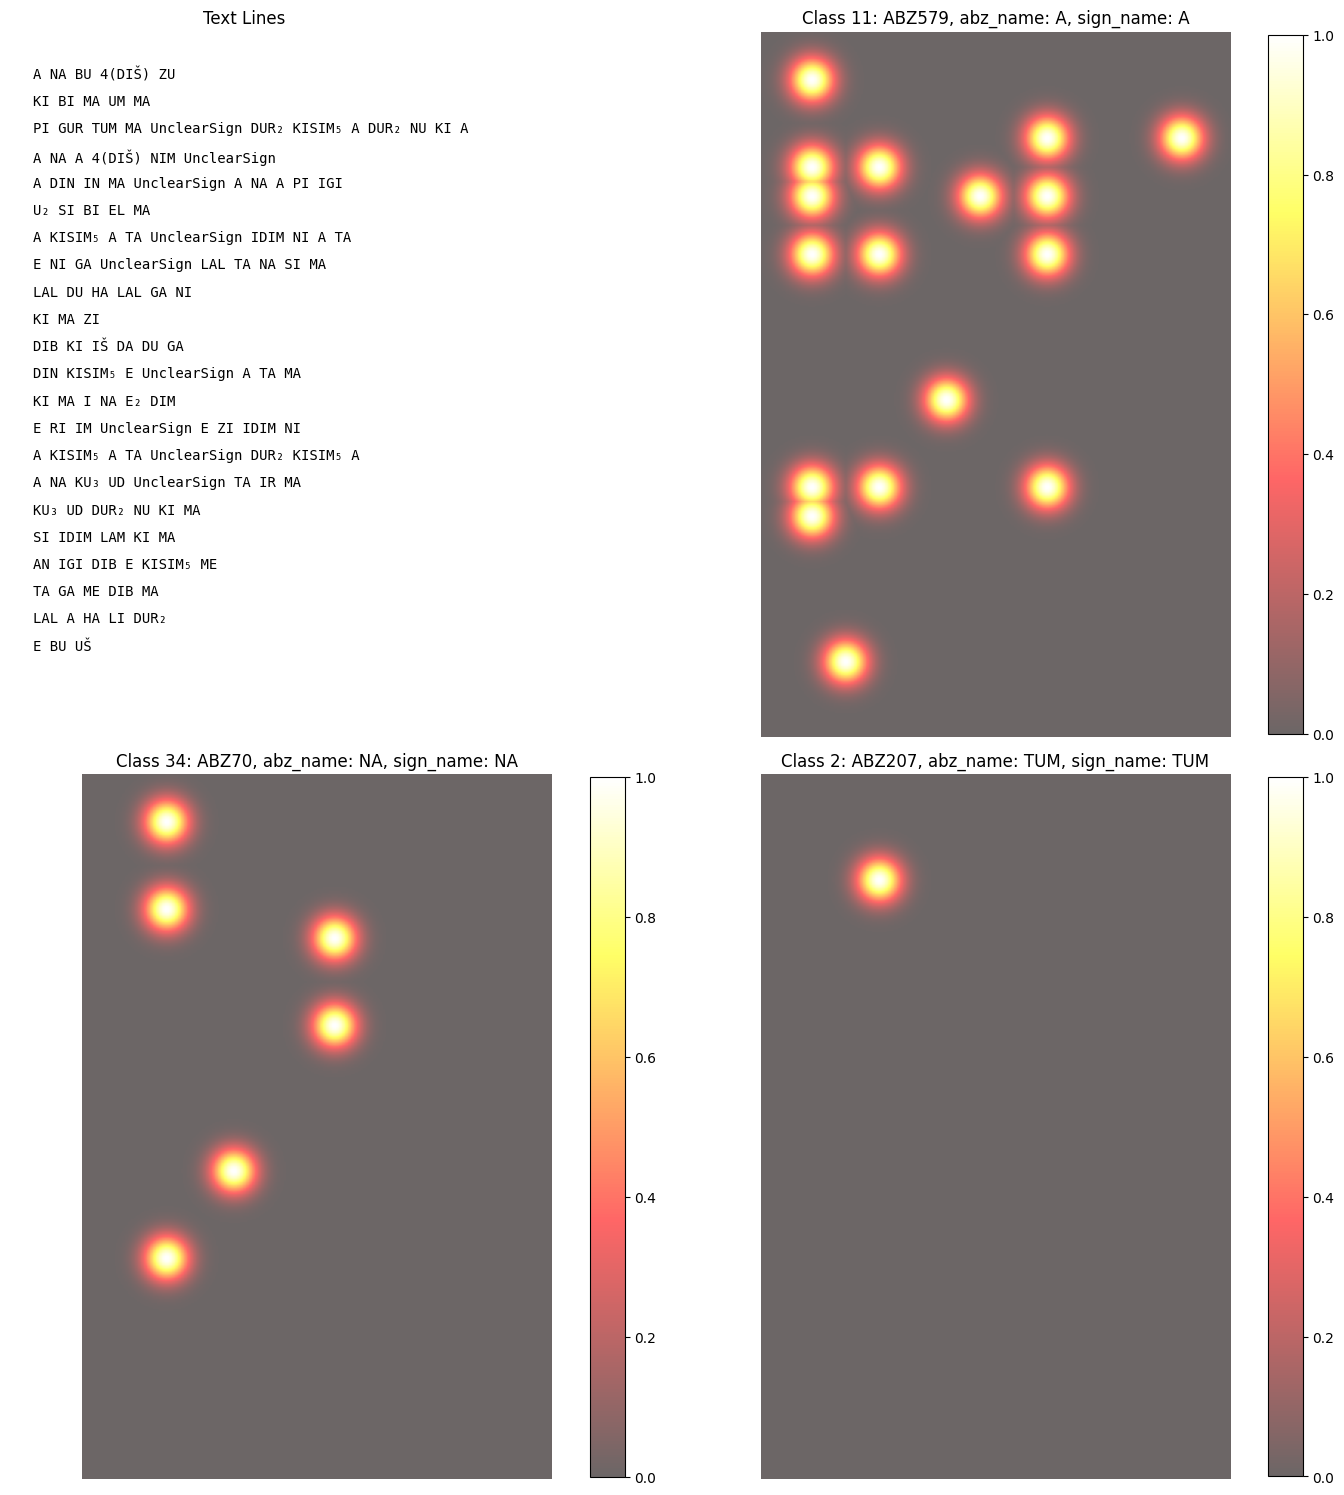

In [11]:
# Visualize text_lines heatmap

# Visualize using the same visualizer
heatmap_visualizer_text = sa.HeatmapVisualizer()

# Use the same class IDs as before for consistency
heatmap_visualizer_text.draw_heatmap(None, heatmap_text, 
                                     channels=(class_id_for_A, class_id_for_NA, 2), 
                                     detection=None, texts=text_lines)
heatmap_visualizer_text.display_result(vis_opt="draw")

In [12]:
# 1. Use normalized cross-correlation to find template position

print(f"Exp heatmap shape: {heatmap.shape}")
print(f"Text heatmap shape: {heatmap_text.shape}")

# Use extracted matching function
top_left_scaled, max_val, top_left_original = sa.match_heatmaps_ncc(
    heatmap, 
    heatmap_text, 
    scale_factor=scale_factor
)

top_left_x_text = top_left_original[0]
top_left_y_text = top_left_original[1]

print(f"Best match correlation (averaged over {heatmap.shape[2]} classes): {max_val:.4f}")
print(f"Match position in text heatmap (scaled): {top_left_scaled}")
print(f"Match position in text heatmap (original): ({top_left_x_text:.2f}, {top_left_y_text:.2f})")

# Convert to full tablet image coordinates
# The text heatmap starts with margin offset, so we need to subtract that
top_left_x_tablet = top_left_x_text - margin
top_left_y_tablet = top_left_y_text - margin

print(f"Match position in full tablet image: ({top_left_x_tablet:.2f}, {top_left_y_tablet:.2f})")

Exp heatmap shape: (163, 181, 173)
Text heatmap shape: (478, 318, 173)
Best match correlation (averaged over 173 classes): 0.0880
Match position in text heatmap (scaled): (11, 17)
Match position in text heatmap (original): (110.00, 170.00)
Match position in full tablet image: (-117.35, -57.35)


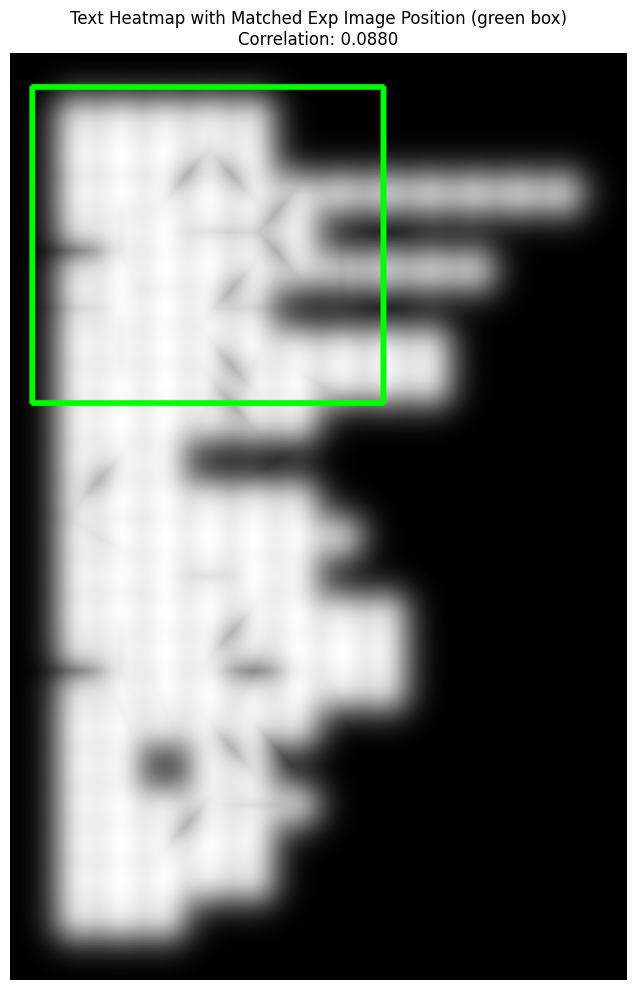

Green box shows matched position of exp image in text heatmap


In [13]:
# 2. Visualize the position of exp image heatmap in text heatmap

# Create visualization using the mixed heatmaps for display
heatmap_exp_mixed = np.mean(heatmap, axis=2)
heatmap_text_mixed = np.mean(heatmap_text, axis=2)

vis_text_heatmap = cv2.normalize(heatmap_text_mixed, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
vis_text_heatmap_rgb = cv2.cvtColor(vis_text_heatmap, cv2.COLOR_GRAY2RGB)

# Draw rectangle at matched position (in scaled coordinates)
bottom_right_scaled = (top_left_scaled[0] + heatmap_exp_mixed.shape[1], 
                       top_left_scaled[1] + heatmap_exp_mixed.shape[0])
cv2.rectangle(vis_text_heatmap_rgb, top_left_scaled, bottom_right_scaled, (0, 255, 0), 2)

# Display
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
plt.imshow(vis_text_heatmap_rgb)
plt.title(f"Text Heatmap with Matched Exp Image Position (green box)\nCorrelation: {max_val:.4f}")
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Green box shows matched position of exp image in text heatmap")

In [14]:
# 3. Assign sign centers from text image into exp image and create bboxes

# Get the dimensions of the exp image
exp_img_height, exp_img_width = exp_image.img.shape[:2]

# Use extracted function to create text-based detections
detection_with_texts = sa.create_text_based_detections(
    text_lines, 
    sa.CLASSES, 
    top_left_x_text, 
    top_left_y_text, 
    margin, 
    avg_width, 
    avg_height, 
    (exp_img_width, exp_img_height)
)

print(f"Created {len(detection_with_texts)} text-based detections for exp image")
print(f"Original detections: {len(exp_image.detections)}")

# Show first few detections as example
if detection_with_texts:
    print("\nFirst 3 text-based detections:")
    for i, det in enumerate(detection_with_texts[:3]):
        print(f"  {i+1}. {det['abz_name']}: bbox={[f'{x:.1f}' for x in det['bbox']]}, center={det['center']}")

Created 49 text-based detections for exp image
Original detections: 43

First 3 text-based detections:
  1. ABZ579: bbox=['117.3', '57.3', '344.7', '254.3'], center=(231.0181127530392, 155.82473498192905)
  2. ABZ70: bbox=['344.7', '57.3', '572.0', '254.3'], center=(458.3635212550654, 155.82473498192905)
  3. ABZ371: bbox=['572.0', '57.3', '799.4', '254.3'], center=(685.7089297570915, 155.82473498192905)


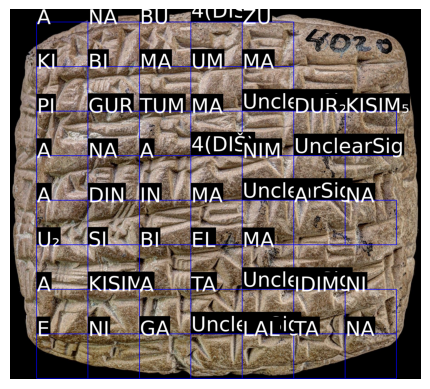

Visualized 49 text-based detections on exp image


In [15]:
# 4. Visualize detection_with_texts for exp image

text_det_bbox_visualizer = sa.BboxVisualizer(boxes_color=(0, 0, 255))  # blue for text-based detections
text_det_bbox_visualizer.draw_boxes(exp_image.img.copy(), detection_with_texts)
text_det_bbox_visualizer.display_result(vis_opt="draw", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text_detections.jpg"))

print(f"Visualized {len(detection_with_texts)} text-based detections on exp image")